# Import required library

In [2]:
import epi_utils as eu
import pandas as pd
import pyranges as pr
import glob

In [64]:
chrom_list = ['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22', 'chrMT', 'chrUn']

# Splitting Histone Data

In [59]:
# Load histone file
histone_df = eu.load_histone_files()
display(histone_df.head())

,chrom,chromStart,chromEnd,name,length,type
0,chr10,119808,119954,chr10_173,146,h3k4me3
1,chr10,119956,120102,chr10_174,146,h3k4me3
2,chr10,122100,122246,chr10_185,146,h3k4me3
3,chr10,122308,122454,chr10_186,146,h3k4me3
4,chr10,180346,180492,chr10_489,146,h3k4me3


In [60]:
histone_chrom = histone_df['chrom'].unique()
display(histone_chrom)

array(['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22'], dtype=object)

In [79]:
pd.DataFrame(histone_df['chrom'].unique()).to_csv("dataset/histone_chromosome.csv", index=False, header=False)

In [61]:
for chrom in histone_chrom:
    df = histone_df[histone_df['chrom'] == chrom]
    print(f"Processing {chrom} with {len(df.index)} data")
    df.to_csv("dataset/histone/" + chr + ".csv", index=False)

Processing chr10 with 14519 data
Processing chr11 with 15712 data
Processing chr12 with 15929 data
Processing chr13 with 7811 data
Processing chr14 with 10687 data
Processing chr15 with 10076 data
Processing chr16 with 13046 data
Processing chr17 with 16532 data
Processing chr18 with 6333 data
Processing chr19 with 15234 data
Processing chr1 with 30373 data
Processing chr2 with 24677 data
Processing chr3 with 19425 data
Processing chrX with 6424 data
Processing chr4 with 14442 data
Processing chrY with 463 data
Processing chr5 with 16617 data
Processing chr6 with 18508 data
Processing chr7 with 16546 data
Processing chr8 with 13445 data
Processing chr9 with 13472 data
Processing chr20 with 8065 data
Processing chr21 with 4116 data
Processing chr22 with 6634 data


# Splitting NCBI RefSeq Data

In [62]:
hg19ncbiRefSeq_df = eu.load_ncbiRefSeq()

In [63]:
display(hg19ncbiRefSeq_df.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chrMT,ncbiRefSeq.2021-05-17,transcript,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,NaN,NaN,16023
1,chrMT,ncbiRefSeq.2021-05-17,exon,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,1,rna-TRNP.1,16023
2,chrMT,ncbiRefSeq.2021-05-17,transcript,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,NaN,NaN,15887
3,chrMT,ncbiRefSeq.2021-05-17,exon,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,1,rna-TRNT.1,15887
4,chrMT,ncbiRefSeq.2021-05-17,transcript,14746,15887,.,+,.,CYTB,YP_003024038.1,CYTB,NaN,NaN,14746


In [80]:
hg19ncbiRefSeq_chrom = hg19ncbiRefSeq_df["Chromosome"].unique()

## Splitting into each `Chromosome`

In [81]:
print(f"Splitting into {len(hg19ncbiRefSeq_chrom)} files.")

num_file = 1

for chrom in hg19ncbiRefSeq_chrom:
    df = hg19ncbiRefSeq_df[hg19ncbiRefSeq_df['Chromosome'] == chrom]
    print(f"File {num_file}: Processing {chrom} with {len(df.index)} data")
    df.to_csv(f"dataset/ncbiRefSeq/raw/{chrom}.csv", index=False)
    num_file+=1

Splitting into 244 files.
File 1: Processing chrMT with 107 data
File 2: Processing chr17_ctg5_hap1 with 2092 data
File 3: Processing chr4_ctg9_hap1 with 257 data
File 4: Processing chr6_ssto_hap7 with 11042 data
File 5: Processing chr6_qbl_hap6 with 13477 data
File 6: Processing chr6_mcf_hap5 with 12916 data
File 7: Processing chr6_mann_hap4 with 11791 data
File 8: Processing chr6_dbb_hap3 with 13190 data
File 9: Processing chr6_cox_hap2 with 13957 data
File 10: Processing chr6_apd_hap1 with 4572 data
File 11: Processing chrX_jh159150_fix with 5358 data
File 12: Processing chrX_jh806600_fix with 1968 data
File 13: Processing chrX_jh806599_fix with 64 data
File 14: Processing chrX_jh806598_fix with 77 data
File 15: Processing chrX_jh806597_fix with 1020 data
File 16: Processing chrX_jh806596_fix with 154 data
File 17: Processing chrX_jh806603_fix with 15 data
File 18: Processing chrX_jh806602_fix with 85 data
File 19: Processing chrX_jh806601_fix with 447 data
File 20: Processing chrX_

## Combining similar `Chromosome`

In [25]:
# Flatten the glob result
def flatten_concatenation(matrix):
    flat_list = []
    for row in matrix:
        flat_list += row
    return flat_list

In [70]:
for chrom in histone_chrom:
    print(f"Processing chromosome: {chrom}")
    file_list = []
    file_list.append(glob.glob(f"dataset/ncbiRefSeq/raw/{chrom}.csv"))
    file_list.append(glob.glob(f"dataset/ncbiRefSeq/raw/{chrom}_*.csv"))
    flat_file_list = flatten_concatenation(file_list)

    data = []
    for filename in flat_file_list:
        print(f"Processing file: {filename}")
        df = pd.read_csv(filename)
        data.append(df)

    df_out = pd.concat(data, axis=0, ignore_index=False)
    df_out.to_csv(f"dataset/ncbiRefSeq/merged/{chrom}.csv", index=False)

print("Splitting ncbiRefSeq FINISHED!")

Processing chromosome: chr10
Processing file: dataset/ncbiRefSeq/raw/chr10.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383543_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383545_alt.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl383546_alt.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_gl877873_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591181_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591182_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh591183_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh636060_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_jh806580_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_kb663606_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr10_ke332501_fix.csv
Processing chromosome: chr11
Processing file: dataset/ncbiRefSeq/raw/chr11.csv
Processing file: dataset/ncbiRefSeq/raw\chr11_gl582973_fix.csv
Processing file: dataset/ncbiRefSeq/raw\chr11_gl949744_fix.csv
Processing file: datase

In [71]:
# Copying 'chrMT'
import shutil

shutil.copy2('dataset/ncbiRefSeq/raw/chrMT.csv', 'dataset/ncbiRefSeq/merged/chrMT.csv')

'dataset/ncbiRefSeq/merged/chrMT.csv'

In [72]:
# Appending 'chrUn'

file_list = []
file_list.append(glob.glob("dataset/ncbiRefSeq/raw/chrUn*.csv"))
flat_file_list = flatten_concatenation(file_list)

data = []
for filename in flat_file_list:
    print(f"Processing file: {filename}")
    df = pd.read_csv(filename)
    data.append(df)

df_out = pd.concat(data, axis=0, ignore_index=False)
df_out.to_csv(f"dataset/ncbiRefSeq/merged/chrUn.csv", index=False)

Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000211.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000212.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000213.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000215.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000218.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000219.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000220.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000224.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000228.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000229.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000230.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000231.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000235.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000236.csv
Processing file: dataset/ncbiRefSeq/raw\chrUn_gl000241.csv


# Counting Histone in TSS

In [73]:
# Counting chrY
chrom = 'chrY'

histone_chr_df = pd.read_csv(f"dataset/histone/{chrom}.csv")
ncbiRefSeq_chr_df = pd.read_csv(f"dataset/ncbiRefSeq/merged/{chrom}.csv")

display(histone_chr_df.head())
print(histone_chr_df.shape)
display(ncbiRefSeq_chr_df.head())
print(ncbiRefSeq_chr_df.shape)

,chrom,chromStart,chromEnd,name,length,type
0,chrY,2649505,2649651,chrY_7,146,h3k4me3
1,chrY,2655498,2655644,chrY_28,146,h3k4me3
2,chrY,2655648,2655794,chrY_29,146,h3k4me3
3,chrY,2664998,2665144,chrY_59,146,h3k4me3
4,chrY,2665253,2665399,chrY_60,146,h3k4me3


(463, 6)


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chrY,ncbiRefSeq.2021-05-17,transcript,59358328,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,NaN,NaN,59360854
1,chrY,ncbiRefSeq.2021-05-17,exon,59358328,59359508,.,-,.,DDX11L16,NR_110561.1,DDX11L16,3.0,NR_110561.1.3,59359508
2,chrY,ncbiRefSeq.2021-05-17,exon,59360006,59360115,.,-,.,DDX11L16,NR_110561.1,DDX11L16,2.0,NR_110561.1.2,59360115
3,chrY,ncbiRefSeq.2021-05-17,exon,59360500,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,1.0,NR_110561.1.1,59360854
4,chrY,ncbiRefSeq.2021-05-17,transcript,59354328,59358341,.,+,.,WASH6P,WASH6P,WASH6P,NaN,NaN,59354328


(8468, 14)


In [74]:
# Counting Histone
ncbiRefSeq_chr_df.loc[:, "histone_count"] = ncbiRefSeq_chr_df.apply(\
                            lambda row: eu.count_histone(histone_chr_df, row), axis=1)

In [75]:
display(ncbiRefSeq_chr_df.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chrY,ncbiRefSeq.2021-05-17,transcript,59358328,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,NaN,NaN,59360854,0
1,chrY,ncbiRefSeq.2021-05-17,exon,59358328,59359508,.,-,.,DDX11L16,NR_110561.1,DDX11L16,3.0,NR_110561.1.3,59359508,0
2,chrY,ncbiRefSeq.2021-05-17,exon,59360006,59360115,.,-,.,DDX11L16,NR_110561.1,DDX11L16,2.0,NR_110561.1.2,59360115,0
3,chrY,ncbiRefSeq.2021-05-17,exon,59360500,59360854,.,-,.,DDX11L16,NR_110561.1,DDX11L16,1.0,NR_110561.1.1,59360854,0
4,chrY,ncbiRefSeq.2021-05-17,transcript,59354328,59358341,.,+,.,WASH6P,WASH6P,WASH6P,NaN,NaN,59354328,0


In [76]:
ncbiRefSeq_chr_df.to_csv(f"dataset/histone_count/{chrom}.csv", index=False)

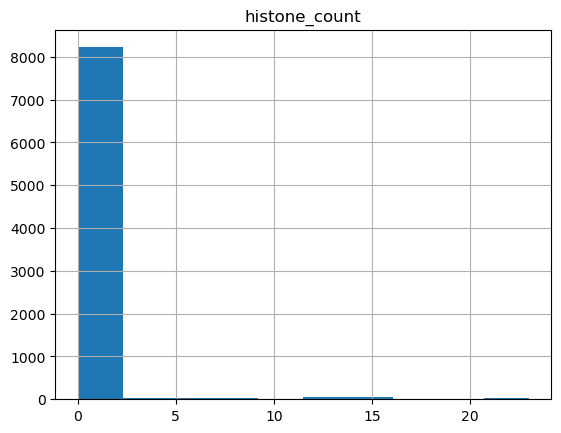

In [77]:
ax = ncbiRefSeq_chr_df.hist(column=["histone_count"])

In [82]:
histone_path = "dataset/histone/"
ncbiRefSeq_path = "dataset/ncbiRefSeq/merged/"
output_path = "dataset/histone_count/"

In [87]:
# chrUn and chrMT histone count should be 0

chrom = 'chrMT'

# Reading file
ncbiRefSeq_chr_df = pd.read_csv(f"{ncbiRefSeq_path}{chrom}.csv")

# Histone count = 0
ncbiRefSeq_chr_df.loc[:, "histone_count"] = 0
display(ncbiRefSeq_chr_df.head())

# Saving the result
ncbiRefSeq_chr_df.to_csv(f"{output_path}{chrom}.csv", index=False)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count
0,chrMT,ncbiRefSeq.2021-05-17,transcript,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,NaN,NaN,16023,0
1,chrMT,ncbiRefSeq.2021-05-17,exon,15955,16023,.,-,.,TRNP,rna-TRNP,TRNP,1.0,rna-TRNP.1,16023,0
2,chrMT,ncbiRefSeq.2021-05-17,transcript,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,NaN,NaN,15887,0
3,chrMT,ncbiRefSeq.2021-05-17,exon,15887,15953,.,+,.,TRNT,rna-TRNT,TRNT,1.0,rna-TRNT.1,15887,0
4,chrMT,ncbiRefSeq.2021-05-17,transcript,14746,15887,.,+,.,CYTB,YP_003024038.1,CYTB,NaN,NaN,14746,0


# Splitting HepG2 data

## Loading and Preparing the Data

In [48]:
# Loading HepG2 data
hepg2_exp = pd.read_csv("dataset/GSM3718064_HepG2_exp.txt", sep="\t")

In [49]:
# Splitting chromosome name and the position
hepg2_exp[["chrom", "chromPos"]] = hepg2_exp["locus"].str.split(':', expand=True)
display(hepg2_exp.head())

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900


In [51]:
# Splitting start and end position
hepg2_exp[["chromStart", "chromEnd"]] = hepg2_exp["chromPos"].str.split('-', expand=True)
display(hepg2_exp.head())

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900


In [52]:
# Correcting the Data Types
hepg2_exp = hepg2_exp.astype({'chromStart': 'int32', 'chromEnd': 'int32'})

In [53]:
# Find the gene's length
hepg2_exp["gene_length"] = hepg2_exp["chromEnd"] - hepg2_exp["chromStart"]
display(hepg2_exp)

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008,918
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581,4690
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597,939
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889,33304
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900,3637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30027,XLOC_030028,XLOC_030028,-,chrY:13319431-13324829,hepg2_hr2,hepg2_hr3,OK,0.337879,0.457897,0.438516,1.137930,0.25685,0.999565,no,chrY,13319431-13324829,13319431,13324829,5398
30028,XLOC_030029,XLOC_030029,-,chrY:13325034-13326120,hepg2_hr2,hepg2_hr3,NOTEST,0.396888,0.357658,-0.150148,0.000000,1.00000,1.000000,no,chrY,13325034-13326120,13325034,13326120,1086
30029,XLOC_030030,XLOC_030030,-,chrY:13331089-13332358,hepg2_hr2,hepg2_hr3,OK,0.477227,0.127331,-1.906090,-1.861920,0.12490,0.999565,no,chrY,13331089-13332358,13331089,13332358,1269
30030,XLOC_030031,XLOC_030031,-,chrY:15053270-15053343,hepg2_hr2,hepg2_hr3,OK,123998.000000,71768.700000,-0.788894,-2.116040,0.04075,0.999565,no,chrY,15053270-15053343,15053270,15053343,73


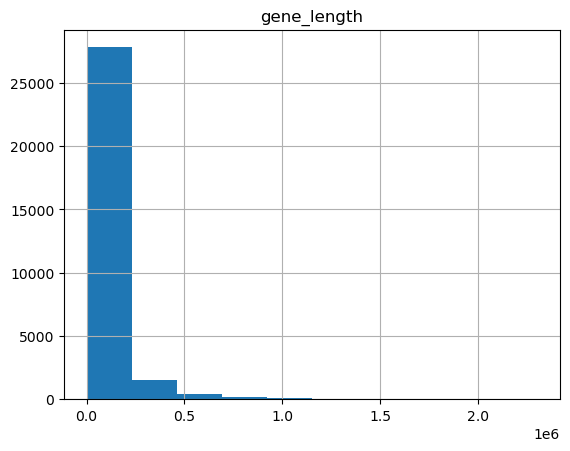

In [41]:
# Find the gene length distribution
ax = hepg2_exp.hist(column=["gene_length"])

In [54]:
# Group the gene length
hepg2_exp.groupby(['gene_length'])['gene_length'].count().to_csv("dataset/HepG2/gene_length.csv")

In [55]:
hepg2_exp.loc[hepg2_exp["gene_length"] >= 2298478]

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
25564,XLOC_025565,XLOC_025565,CNTNAP2,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,OK,0.440670,0.565965,0.361012,0.975025,0.32435,0.999565,no,chr7,145813452-148118088,145813452,148118088,2304636
25565,XLOC_025566,XLOC_025566,MIR548F3,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr7,145813452-148118088,145813452,148118088,2304636
25566,XLOC_025567,XLOC_025567,MIR548T,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr7,145813452-148118088,145813452,148118088,2304636
26153,XLOC_026154,XLOC_026154,MIR548I4,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr7,145813452-148118088,145813452,148118088,2304636
26154,XLOC_026155,XLOC_026155,MIR548F4,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr7,145813452-148118088,145813452,148118088,2304636
26155,XLOC_026156,XLOC_026156,CNTNAP2,chr7:145813452-148118088,hepg2_hr2,hepg2_hr3,OK,0.493111,1.363250,1.467070,1.210590,0.24385,0.999565,no,chr7,145813452-148118088,145813452,148118088,2304636
28042,XLOC_028043,XLOC_028043,PTPRD,chr9:8314245-10612723,hepg2_hr2,hepg2_hr3,NOTEST,0.027892,0.014818,-0.912474,0.000000,1.00000,1.000000,no,chr9,8314245-10612723,8314245,10612723,2298478


## Splitting into each Chromosome

In [56]:
# Find the unique chromosome name
pd.DataFrame(hepg2_exp["chrom"].unique(), columns=["chrom"]).to_csv("dataset/HepG2_Chromosome.csv", index=False, header=False)
hepg2_exp_chrom = hepg2_exp["chrom"].unique()
print(hepg2_exp_chrom)

['chr1' 'chr10' 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17'
 'chr17_ctg5_hap1' 'chr17_gl000205_random' 'chr18' 'chr19'
 'chr19_gl000209_random' 'chr1_gl000191_random' 'chr2' 'chr20' 'chr21'
 'chr22' 'chr3' 'chr4' 'chr4_ctg9_hap1' 'chr4_gl000194_random' 'chr5'
 'chr6' 'chr6_apd_hap1' 'chr6_cox_hap2' 'chr6_dbb_hap3' 'chr6_mann_hap4'
 'chr6_mcf_hap5' 'chr6_qbl_hap6' 'chr6_ssto_hap7' 'chr7' 'chr8' 'chr9'
 'chrM' 'chrUn_gl000211' 'chrUn_gl000212' 'chrUn_gl000218'
 'chrUn_gl000219' 'chrUn_gl000220' 'chrUn_gl000222' 'chrUn_gl000223'
 'chrUn_gl000228' 'chrX' 'chrY']


In [57]:
print(f"Splitting into {len(hepg2_exp_chrom)} files.")

num_file = 1

for chrom in hepg2_exp_chrom:
    df = hepg2_exp[hepg2_exp['chrom'] == chrom]
    print(f"File {num_file}: Processing {chrom} with {len(df.index)} data")
    df.to_csv(f"dataset/HepG2/raw/{chrom}.csv", index=False)
    num_file+=1

Splitting into 46 files.
File 1: Processing chr1 with 2867 data
File 2: Processing chr10 with 1181 data
File 3: Processing chr11 with 1618 data
File 4: Processing chr12 with 1395 data
File 5: Processing chr13 with 542 data
File 6: Processing chr14 with 1030 data
File 7: Processing chr15 with 984 data
File 8: Processing chr16 with 1149 data
File 9: Processing chr17 with 1581 data
File 10: Processing chr17_ctg5_hap1 with 22 data
File 11: Processing chr17_gl000205_random with 1 data
File 12: Processing chr18 with 454 data
File 13: Processing chr19 with 1711 data
File 14: Processing chr19_gl000209_random with 8 data
File 15: Processing chr1_gl000191_random with 1 data
File 16: Processing chr2 with 1880 data
File 17: Processing chr20 with 785 data
File 18: Processing chr21 with 419 data
File 19: Processing chr22 with 656 data
File 20: Processing chr3 with 1581 data
File 21: Processing chr4 with 1137 data
File 22: Processing chr4_ctg9_hap1 with 6 data
File 23: Processing chr4_gl000194_random

## Combining similar chromosome

In [58]:
hepg2_exp_combined_chrom = ['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16',
       'chr17', 'chr18', 'chr19', 'chr1', 'chr2', 'chr3', 'chrX', 'chr4',
       'chrY', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr20', 'chr21',
       'chr22', 'chrM', 'chrUn']

In [59]:
for chrom in hepg2_exp_combined_chrom:
    print(f"Processing chromosome: {chrom}")
    file_list = []
    file_list.append(glob.glob(f"dataset/HepG2/raw/{chrom}.csv"))
    file_list.append(glob.glob(f"dataset/HepG2/raw/{chrom}_*.csv"))
    flat_file_list = flatten_concatenation(file_list)

    data = []
    for filename in flat_file_list:
        print(f"Processing file: {filename}")
        df = pd.read_csv(filename)
        data.append(df)

    df_out = pd.concat(data, axis=0, ignore_index=False)
    df_out.to_csv(f"dataset/HepG2/merged/{chrom}.csv", index=False)

print("Splitting HepG2 FINISHED!")

Processing chromosome: chr10
Processing file: dataset/HepG2/raw/chr10.csv
Processing chromosome: chr11
Processing file: dataset/HepG2/raw/chr11.csv
Processing chromosome: chr12
Processing file: dataset/HepG2/raw/chr12.csv
Processing chromosome: chr13
Processing file: dataset/HepG2/raw/chr13.csv
Processing chromosome: chr14
Processing file: dataset/HepG2/raw/chr14.csv
Processing chromosome: chr15
Processing file: dataset/HepG2/raw/chr15.csv
Processing chromosome: chr16
Processing file: dataset/HepG2/raw/chr16.csv
Processing chromosome: chr17
Processing file: dataset/HepG2/raw/chr17.csv
Processing file: dataset/HepG2/raw\chr17_ctg5_hap1.csv
Processing file: dataset/HepG2/raw\chr17_gl000205_random.csv
Processing chromosome: chr18
Processing file: dataset/HepG2/raw/chr18.csv
Processing chromosome: chr19
Processing file: dataset/HepG2/raw/chr19.csv
Processing file: dataset/HepG2/raw\chr19_gl000209_random.csv
Processing chromosome: chr1
Processing file: dataset/HepG2/raw/chr1.csv
Processing 

## Changing 'chrM' into 'chrMT'

In [61]:
import os

hepg2_chrMT = pd.read_csv("dataset/HepG2/merged/chrM.csv")
hepg2_chrMT.head()

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_028761,XLOC_028761,-,chrM:0-16571,hepg2_hr2,hepg2_hr3,HIDATA,0.0,0.0,0.0,0.0,1.0,1.0,no,chrM,0-16571,0,16571,16571


In [62]:
hepg2_chrMT["chrom"] = "chrMT"
hepg2_chrMT.head()

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_028761,XLOC_028761,-,chrM:0-16571,hepg2_hr2,hepg2_hr3,HIDATA,0.0,0.0,0.0,0.0,1.0,1.0,no,chrMT,0-16571,0,16571,16571


In [63]:
hepg2_chrMT.to_csv(f"dataset/HepG2/merged/chrMT.csv", index=False)

# Counting Gene Expression in the +/-2k from TSS

In [1]:
from tqdm.auto import tqdm
tqdm.pandas()

In [3]:
def count_gene(gene_df, row, threshold = 0.8, tss_length = 4000):
    tss = row["tss"]
    hist_df = gene_df.loc[  # Inside the +/- 2k from TSS
                             (((gene_df["chromStart"] >= tss - 2000) & (gene_df["chromEnd"] <= tss + 2000)) |
                             
                             # Intersect with -2k or +2 from TSS
                             (((gene_df["chromEnd"] - (tss - 2000))/tss_length).between(threshold, 1.0)) |
                             ((((tss + 2000) - gene_df["chromStart"])/tss_length).between(threshold, 1.0))) |
                             
                             # TSS inside the gene
                             ((tss + 2000 <= gene_df["chromEnd"]) & (tss - 2000 >= gene_df["chromStart"]))
                        ]
    
    return len(hist_df.index)

In [9]:
# Counting chrY
chrom = 'chr1'

gene_chr_df = pd.read_csv(f"dataset/HepG2/merged/{chrom}.csv")
ncbiRefSeq_chr_df = pd.read_csv(f"dataset/ncbiRefSeq/merged/{chrom}.csv")

display(gene_chr_df.head())
print(gene_chr_df.shape)
display(ncbiRefSeq_chr_df.head())
print(ncbiRefSeq_chr_df.shape)


,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,chrom,chromPos,chromStart,chromEnd,gene_length
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008,918
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581,4690
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597,939
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889,33304
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900,3637


(2868, 19)


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433


(193194, 14)


In [10]:
# Counting Gene
ncbiRefSeq_chr_df.loc[:, "gene_count"] = ncbiRefSeq_chr_df.progress_apply(\
                            lambda row: count_gene(gene_chr_df, row), axis=1)

  0%|          | 0/193194 [00:00<?, ?it/s]

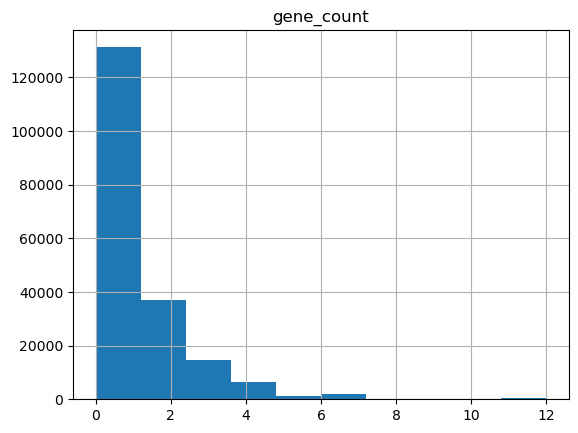

In [11]:
ax = ncbiRefSeq_chr_df.hist(column=["gene_count"])

In [12]:
ncbiRefSeq_chr_df.to_csv(f"dataset/gene_count/{chrom}.csv", index=False)